In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import pathlib


# **DATOS PROCESADOS**

## > Apilando todos los archivos de la carpeta "restaurantes csv", en un solo dataframe:

In [ ]:
# Getting the path with "pathlib" library
folder = pathlib.Path("/content/drive/MyDrive/Projectos de Data/FinalProject_Gp5/data/Datos Procesados/restaurantes csv")

df_restaurants = pd.DataFrame() # Starting with a empty dataframe

for restaurant_file in folder.iterdir():

  df_to_concat = pd.read_csv(restaurant_file)
  df_restaurants = pd.concat([df_restaurants, df_to_concat])

df_restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46337 entries, 0 to 1679
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_nombre              46337 non-null  object 
 1   nombre                 45796 non-null  object 
 2   direccion              46077 non-null  object 
 3   id_ciudad              46337 non-null  object 
 4   ciudad                 46337 non-null  object 
 5   codigo_postal          46336 non-null  object 
 6   latitud                46337 non-null  float64
 7   longitud               46337 non-null  float64
 8   puntuacion_yelp        35497 non-null  float64
 9   categories             36636 non-null  object 
 10  puntuacion_usuarios    36636 non-null  float64
 11  anio                   46337 non-null  int64  
 12  analisis_sentimientos  36636 non-null  float64
 13  estado                 10840 non-null  object 
 14  pais                   9160 non-null   object 
dtypes: float

## > Reteniendo las columnas que son de imporancia para el cálculo de los KPI's:

In [ ]:
df_restaurants = df_restaurants[['id_nombre', 'nombre', 'id_ciudad','ciudad', 'categories', 'analisis_sentimientos','puntuacion_usuarios','anio']]
df_restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46337 entries, 0 to 1679
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_nombre              46337 non-null  object 
 1   nombre                 45796 non-null  object 
 2   id_ciudad              46337 non-null  object 
 3   ciudad                 46337 non-null  object 
 4   categories             36636 non-null  object 
 5   analisis_sentimientos  36636 non-null  float64
 6   puntuacion_usuarios    36636 non-null  float64
 7   anio                   46337 non-null  int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 3.2+ MB


### > Exploramos los datos para ver la cantidad de información que tenemos por ciudad, en particular las ciudades con la menor y mayor cantidad de de datos para el análisis:

In [ ]:
df_restaurants['ciudad'].value_counts()[0:10,]

,count
ciudad,
Tampa,14497
San Petersburgo,3190
Clearwater,3158
Brandon,2086
Largo,1353
Hialeah,1111
Apopka,1095
New Port Richey,1076
Dunedin,1067


## > Trabajaremos con las 5 ciudades que tienen más datos, para dar una muestra de como se comportan los KPI's

In [ ]:
list_top_cities = df_restaurants['ciudad'].value_counts()[:5,].index # Generando lista con las 5 ciudades con más datos
kpi = df_restaurants[df_restaurants['ciudad'].isin(list_top_cities)] # Generando un subset con las 5 ciudades
kpi = kpi.dropna(subset=['puntuacion_usuarios', 'anio']) # Eliminando valores nulos para los atributos de puntuación y año
kpi['anio'] = kpi['anio'].astype(str)

# Se crea el nuevo atributo, "Good_puntuaction": True si es mayor o igual a 4 y False si no
kpi = kpi.assign(Good_Punctuation = lambda x: (x['puntuacion_usuarios'].astype(int) >= 4))
kpi.head(2)

,id_nombre,nombre,id_ciudad,ciudad,categories,analisis_sentimientos,puntuacion_usuarios,anio,Good_Punctuation
0,0018,Mr. Dunderbak's,RGTW,Tampa,"Beer, Wine & Spirits, Food, Pubs, German, Amer...",1.0,5.0,2006,True
1,0040,Beef 'O' Brady's,RGTW,Tampa,"Sports Bars, Fast Food, Bars, American (Tradit...",0.5,2.0,2006,False


# **I) KPI1**

In [ ]:
kpi1_dict = {} # Empty dictionary
cities = kpi['ciudad'].unique() # Lista con las ciudades seleccionadas
anios = kpi['anio'].sort_values().unique() # Lista con los años de los cuales disponemos de datos

for city in cities:

  kpi1 = kpi[(kpi['ciudad'] == city)]
  kpi1_lista = []
  for anio in anios:

    num = np.shape(kpi1[(kpi1['anio'] == anio) & kpi1['Good_Punctuation'] == True])[0]
    den = np.shape(kpi1[kpi1['anio'] == anio])[0]

    if den != 0:
      ratio = round((num/den)*100, 1)

    else:
      ratio = np.nan

    kpi1_lista.append(ratio)

  kpi1_dict[city] = kpi1_lista


kpi1_df = pd.DataFrame(kpi1_dict, index = anios)

In [ ]:
kpi1_df.head(3)

,Tampa,Brandon,Clearwater,Largo,San Petersburgo
2006,66.0,28.6,76.9,40.0,83.3
2007,66.7,62.5,68.2,100.0,52.2
2008,57.1,61.5,58.0,75.0,57.4


## Plotting the results:

<Axes: >

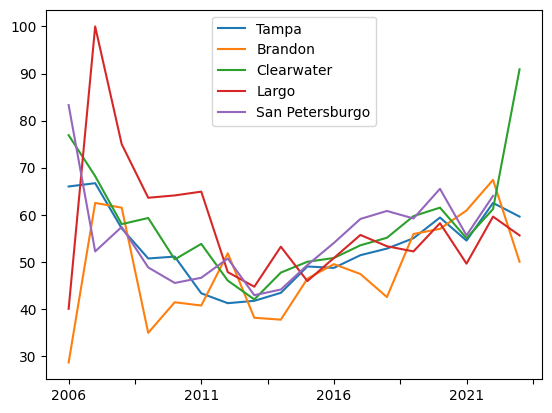

In [ ]:
kpi1_df.plot()

In [ ]:
kpi1.to_csv('/content/drive/MyDrive/Projectos de Data/FinalProject_Gp5/data/Datos Procesados/restaurantes csv/kpi1.csv')

# **II) KPI2**

In [ ]:
kpi2_dict = {} # Empty dictionary
cities = kpi['ciudad'].unique() # Lista con las ciudades seleccionadas
anios = kpi['anio'].sort_values().unique() # Lista con los años de los cuales disponemos de datos

for city in cities:

  kpi2 = kpi[(kpi['ciudad'] == city)]
  kpi2_lista = []
  for anio in anios:

    average_stars = kpi2['puntuacion_usuarios'][kpi2['anio'] == anio].mean()
    kpi2_lista.append(average_stars)

  kpi2_dict[city] = kpi2_lista

kpi2_df = pd.DataFrame(kpi2_dict, index = anios)

In [ ]:
kpi2_df.head(3)

,Tampa,Brandon,Clearwater,Largo,San Petersburgo
2006,3.869072,3.042857,3.873077,2.300,4.083333
2007,3.917829,3.312500,3.940909,4.000,3.617391
2008,3.768333,3.684615,3.872000,3.825,3.547059


<Axes: >

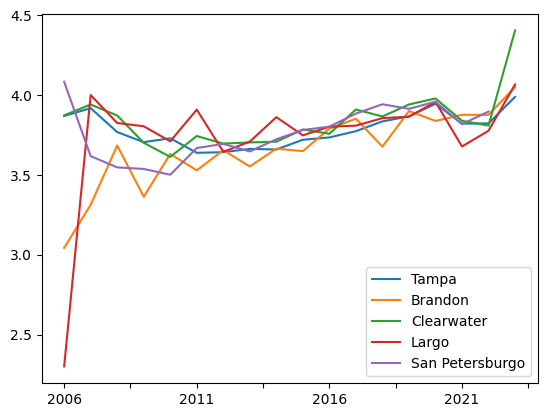

In [ ]:
kpi2_df.plot()

In [ ]:
kpi2.to_csv('/content/drive/MyDrive/Projectos de Data/FinalProject_Gp5/data/Datos Procesados/restaurantes csv/kpi2.csv')

## IV) ¿Cuáles son las ciudades con mejores puntuaciones, pero pocos restaurantes?

In [ ]:
df_restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46337 entries, 0 to 1679
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_nombre              46337 non-null  object 
 1   nombre                 45796 non-null  object 
 2   id_ciudad              46337 non-null  object 
 3   ciudad                 46337 non-null  object 
 4   categories             36636 non-null  object 
 5   analisis_sentimientos  36636 non-null  float64
 6   puntuacion_usuarios    36636 non-null  float64
 7   anio                   46337 non-null  int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 3.2+ MB
